# 01 · Preparación de datos

Clasificador de proteínas por secuencia: **clase enzimática (primer nivel del número EC, 7 clases)**.

Datos: descarga manual de Swiss-Prot (UniProtKB) en 7 archivos TSV, uno por clase EC, en `data/raw/`

Pasos de este notebook:
1. Cargar y juntar los 7 archivos
2. Quitar duplicados
3. Calcular la clase desde la columna `EC number`
4. Quitar secuencias con letras no estándar
5. Exploración rápida
6. Equilibrar las clases y guardar el CSV limpio

> Fecha de descarga y consulta usada en UniProtKB (Swiss-Prot)
> - Fecha: 6/10/2026
> - Consulta: `(reviewed:true) AND (ec:X.*) AND (length:[50 TO 1000])`

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
MAX_POR_CLASE = 1500 
SEMILLA = 42

## 1. Cargar y juntar los 7 archivos

In [7]:
archivos = sorted(RAW.glob("enzimas_ec*.tsv"))
print([a.name for a in archivos])
assert len(archivos) == 7, f"Se esperaban 7 archivos y hay {len(archivos)}"

df = pd.concat([pd.read_csv(f, sep="\t") for f in archivos], ignore_index=True)
print(df.shape)
print(df.columns.tolist())
df.head()

['enzimas_ec1.tsv', 'enzimas_ec2.tsv', 'enzimas_ec3.tsv', 'enzimas_ec4.tsv', 'enzimas_ec5.tsv', 'enzimas_ec6.tsv', 'enzimas_ec7.tsv']
(275743, 7)
['Entry', 'Entry Name', 'Protein names', 'Organism', 'Length', 'Sequence', 'EC number']


,Entry,Entry Name,Protein names,Organism,Length,Sequence,EC number
0,A0A059TC02,CCR1_PETHY,Cinnamoyl-CoA reductase 1 (Ph-CCR1) (EC 1.2.1....,Petunia hybrida (Petunia),333,MRSVSGQVVCVTGAGGFIASWLVKILLEKGYTVRGTVRNPDDPKNG...,1.2.1.44
1,A0A072ULZ1,GLB12_MEDTR,Anaerobic nitrite reductase Glb1-2 (EC 1.7.2.-...,Medicago truncatula (Barrel medic) (Medicago t...,351,MEENKKTVDGSVDFTEEQEALVVKSWNAMKNNSCDLSLKFFTKILE...,1.7.2.-
2,A0A072VDF2,CCR1_MEDTR,Cinnamoyl-CoA reductase 1 (Mt-CCR1) (EC 1.2.1....,Medicago truncatula (Barrel medic) (Medicago t...,342,MPAATAAAAAESSSVSGETICVTGAGGFIASWMVKLLLEKGYTVRG...,1.2.1.-; 1.2.1.44
3,A0A075BSX9,HLNO_SHIS7,(S)-6-hydroxynicotine oxidase ((S)-6HN oxidase...,Shinella sp. (strain HZN7),437,MTEKIYDAIVVGAGFSGLVAARELSAQGRSVLIIEARHRLGGRTHV...,1.5.3.5
4,A0A075TMP8,PATI_PENEN,Cytochrome P450 monooxygenase patI (EC 1.-.-.-...,Penicillium expansum (Blue mold rot fungus),526,MDILQLAPTHLLAILLSSTSALFLITYLLRAGHRPSDLPNGPPTVP...,1.-.-.-


## 2. Quitar duplicados

Una proteína con números EC de varias clases puede aparecer en más de un archivo.

In [ ]:
col_id = "Entry"
antes = len(df)

df = df.drop_duplicates(subset=col_id).reset_index(drop=True)
print(f"Filas: {antes} -> {len(df)} ({antes - len(df)} duplicadas eliminadas)")

Identificador usado: Entry
Filas: 275743 -> 269143 (6600 duplicadas eliminadas)


## 3. Calcular la clase desde la columna EC

La clase se saca de `EC number` (no del nombre del archivo). Si una proteína tiene
números EC de **clases distintas**, la etiqueta es ambigua y se descarta.

In [9]:
def clase_ec(ec):
    """Devuelve el primer nivel del EC ('2.7.11.1' -> '2') o None si es ambiguo/vacío."""
    if pd.isna(ec):
        return None
    clases = {e.strip().split(".")[0] for e in str(ec).split(";") if e.strip()}
    return clases.pop() if len(clases) == 1 else None


df["clase"] = df["EC number"].apply(clase_ec)
print("Descartadas por clase ambigua o sin EC:", df["clase"].isna().sum())

df = df.dropna(subset=["clase"]).reset_index(drop=True)
df["clase"] = df["clase"].astype(int)
df["clase"].value_counts().sort_index()

Descartadas por clase ambigua o sin EC: 6185


clase
1    33692
2    90269
3    57901
4    23969
5    15637
6    26956
7    14534
Name: count, dtype: int64

## 4. Quitar secuencias con letras no estándar

Las que contienen `X`, `B`, `Z`, `U` u `O` romperían el cálculo de frecuencias
de aminoácidos, dipéptidos y tripéptidos.

In [10]:
VALIDOS = set("ACDEFGHIKLMNPQRSTVWY")

es_valida = df["Sequence"].apply(lambda s: set(s) <= VALIDOS)
print("Secuencias con letras raras:", (~es_valida).sum())

df = df[es_valida].reset_index(drop=True)
print(df.shape)
df["clase"].value_counts().sort_index()

Secuencias con letras raras: 741
(262217, 8)


clase
1    33463
2    90079
3    57790
4    23862
5    15610
6    26941
7    14472
Name: count, dtype: int64

## 5. Exploración rápida

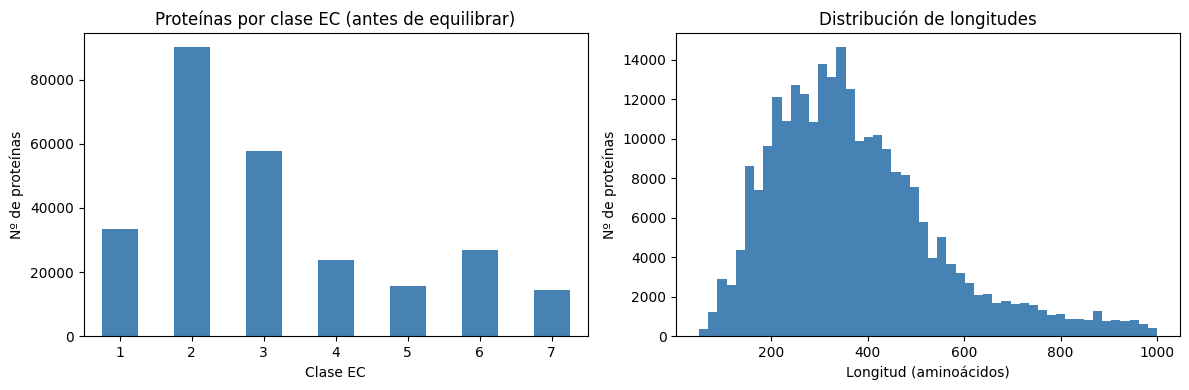

In [11]:
conteo = df["clase"].value_counts().sort_index()

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

conteo.plot(kind="bar", ax=ejes[0], color="steelblue")
ejes[0].set_title("Proteínas por clase EC (antes de equilibrar)")
ejes[0].set_xlabel("Clase EC")
ejes[0].set_ylabel("Nº de proteínas")
ejes[0].tick_params(axis="x", rotation=0)

ejes[1].hist(df["Length"], bins=50, color="steelblue")
ejes[1].set_title("Distribución de longitudes")
ejes[1].set_xlabel("Longitud (aminoácidos)")
ejes[1].set_ylabel("Nº de proteínas")

plt.tight_layout()
plt.show()

In [12]:
print("Longitud por clase:")
print(df.groupby("clase")["Length"].describe().round(1))

print("\nOrganismos distintos:", df["Organism"].nunique())
print(df["Organism"].value_counts().head(10))

Longitud por clase:
         count   mean    std   min    25%    50%    75%     max
clase                                                          
1      33463.0  383.6  153.9  50.0  296.0  351.0  466.0  1000.0
2      90079.0  355.8  157.7  50.0  248.0  327.0  417.0  1000.0
3      57790.0  353.5  189.4  50.0  204.0  311.0  454.0  1000.0
4      23862.0  341.9  157.0  53.0  223.0  320.0  437.0   999.0
5      15610.0  370.5  156.6  52.0  248.0  350.0  452.0   998.0
6      26941.0  504.3  171.9  51.0  393.0  472.0  585.0  1000.0
7      14472.0  376.6  211.5  50.0  209.0  345.0  505.0   999.0

Organismos distintos: 7884
Organism
Arabidopsis thaliana (Mouse-ear cress)                                   5471
Homo sapiens (Human)                                                     3831
Mus musculus (Mouse)                                                     3716
Rattus norvegicus (Rat)                                                  2083
Escherichia coli (strain K12)                          

## 6. Equilibrar las clases y guardar

Se toma la misma cantidad de proteínas de cada clase: el tamaño de la clase más pequeña,
con un tope de `MAX_POR_CLASE`.

In [13]:
n = min(df["clase"].value_counts().min(), MAX_POR_CLASE)
print("Muestras por clase:", n)

df_bal = (
    df.groupby("clase", group_keys=False)
      .sample(n=n, random_state=SEMILLA)
      .reset_index(drop=True)
)

PROCESSED.mkdir(parents=True, exist_ok=True)
ruta = PROCESSED / "enzimas_equilibrado.csv"
df_bal.to_csv(ruta, index=False)

print("Guardado en:", ruta, "| filas:", len(df_bal))
df_bal["clase"].value_counts().sort_index()

Muestras por clase: 1500
Guardado en: ..\data\processed\enzimas_equilibrado.csv | filas: 10500


clase
1    1500
2    1500
3    1500
4    1500
5    1500
6    1500
7    1500
Name: count, dtype: int64